<a href="https://colab.research.google.com/github/marcovoc300/Final_ia/blob/main/IA_entrega_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q groq pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 2.9 MB/s eta 0:00:00


In [3]:
# PROYECTO: DataStory AI - Módulo Texto-Texto (Conexión Dinámica a Groq)


import os
from IPython.display import Markdown, display
from groq import Groq

# 1. RECUPERACIÓN DE API KEY (Colab Secrets)
groq_api_key = None
try:
    from google.colab import userdata

    groq_api_key = userdata.get("GROQ_API_KEY")
except Exception:
    groq_api_key = os.environ.get("GROQ_API_KEY")

if not groq_api_key:
    raise ValueError(
        "❌ No se encontró la 'GROQ_API_KEY'. Verifica los Secrets (ícono de llave) en Colab."
    )

client = Groq(api_key=groq_api_key)

# 2. PROMPT ENGINEERING (Fast Prompting)
SYSTEM_PROMPT = """
[ROL]: Sos un Consultor Senior en Data Storytelling para PyMEs.
[OBJETIVO]: Transformar métricas de negocio en un informe ejecutivo claro y orientativo.

[RESTRICCIONES]:
1. No utilices jerga estadística compleja.
2. Mantené un tono profesional, directo y claro.
3. Basate ÚNICAMENTE en los datos provistos.

[ESTRUCTURA OBLIGATORIA DE RESPUESTA]:
1. TITULAR DE IMPACTO: Frase de máximo 12 palabras con el hallazgo principal del periodo.
2. EL CONFLICTO (Qué pasó): Diagnóstico claro de la métrica desviada o la oportunidad detectada.
3. EL CLÍMAX (Por qué pasó / Causa raíz): Explicación de la causa raíz analizando las variables provistas.
4. LA RESOLUCIÓN (Qué hacer ahora): 3 acciones tácticas priorizadas con impacto estimado.
"""

USER_DATA_INPUT = """
ENTRADA DE DATOS (E-Commerce PyME):
- Ventas del mes: $12.500.000 (-15% vs mes anterior)
- Tráfico web: +20% por pauta publicitaria
- Tasa de conversión: cayó de 2.1% a 1.2%
- Abandono de carrito: +40% en checkout/envíos
- Quejas: 65% asociadas a costos del nuevo operador logístico

Generá el informe ejecutivo según la estructura obligatoria.
"""

# 3. CONSULTA DINÁMICA DE MODELOS ACTIVOS EN TU CUENTA
try:
    print("Obteniendo catálogo de modelos activos desde Groq...")
    modelos_disponibles = client.models.list()
    lista_modelos = [m.id for m in modelos_disponibles.data]

    # Filtrar modelos de chat compatibles (excluyendo Whisper o de solo audio/transcripción)
    modelos_chat = [m for m in lista_modelos if "whisper" not in m]

    if not modelos_chat:
        raise RuntimeError("No se encontraron modelos de chat activos.")

    print(
        f"✓ Modelos de chat detectados en tu cuenta: {len(modelos_chat)} modelos."
    )

except Exception as e:
    print(f"⚠ Error al listar modelos: {e}")
    # En caso de fallo en la API de modelos, usar IDs por defecto
    modelos_chat = ["llama-3.3-70b-versatile", "llama-3.1-8b-instant"]

# 4. EJECUCIÓN EN CASCADA CON MODELOS DETECTADOS
reporte_generado = None

for modelo_id in modelos_chat:
    try:
        print(f"Probando inferencia con el modelo: '{modelo_id}'...")
        response = client.chat.completions.create(
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": USER_DATA_INPUT},
            ],
            model=modelo_id,
            temperature=0.2,
        )
        reporte_generado = response.choices[0].message.content
        print(f"✓ Éxito con el modelo: {modelo_id}\n")
        break
    except Exception as e:
        print(f"❌ El modelo '{modelo_id}' no pudo procesar la llamada: {e}\n")

# 5. DESPLIEGUE DEL RESULTADO EN COLAB
if reporte_generado:
    display(Markdown("## Reporte Ejecutivo Generado (DataStory AI)"))
    display(Markdown(reporte_generado))
else:
    print(
        "❌ Error crítico: Ningún modelo activo pudo completar la inferencia."
    )

Obteniendo catálogo de modelos activos desde Groq...
✓ Modelos de chat detectados en tu cuenta: 11 modelos.
Probando inferencia con el modelo: 'meta-llama/llama-prompt-guard-2-22m'...
❌ El modelo 'meta-llama/llama-prompt-guard-2-22m' no pudo procesar la llamada: Error code: 400 - {'error': {'message': 'failed to template request: failed to render text output: messages must contains a single user message for text classification models', 'type': 'invalid_request_error'}}

Probando inferencia con el modelo: 'openai/gpt-oss-20b'...
✓ Éxito con el modelo: openai/gpt-oss-20b



## Reporte Ejecutivo Generado (DataStory AI)

**TITULAR DE IMPACTO**  
Ventas caen 15 % pese a tráfico +20 %: la conversión se desploma.

**EL CONFLICTO**  
El descenso de ingresos se debe a que, aunque el sitio recibe más visitantes, la tasa de conversión se redujo de 2,1 % a 1,2 % y el abandono de carrito aumentó un 40 %. Además, la mayoría de las quejas (65 %) se relacionan con los costos del nuevo operador logístico.

**EL CLÍMAX (Causa raíz)**  
1. **Proceso de checkout**: la experiencia de compra se vuelve más compleja o lenta, lo que provoca que los usuarios abandonen el carrito.  
2. **Costos logísticos**: el aumento de tarifas genera descontento y puede disuadir a los clientes de completar la compra.  
3. **Segmentación de la pauta**: la campaña publicitaria atrae tráfico que no está alineado con el perfil de comprador habitual, reduciendo la probabilidad de conversión.

**LA RESOLUCIÓN**  
1. **Rediseñar el checkout** (prioridad alta) – simplificar pasos, ofrecer opciones de pago rápido y mostrar costos claros. *Impacto estimado*: +5 % en la tasa de conversión, +10 % en ventas.  
2. **Negociar tarifas con el operador logístico** (prioridad media) – buscar descuentos por volumen o alternativas de envío. *Impacto estimado*: reducción de costos logísticos en 8 %, mejorando la satisfacción del cliente.  
3. **Reorientar la pauta publicitaria** (prioridad baja) – enfocar anuncios en segmentos con mayor probabilidad de compra y usar remarketing. *Impacto estimado*: +3 % en la tasa de conversión y mejor uso del presupuesto de marketing.

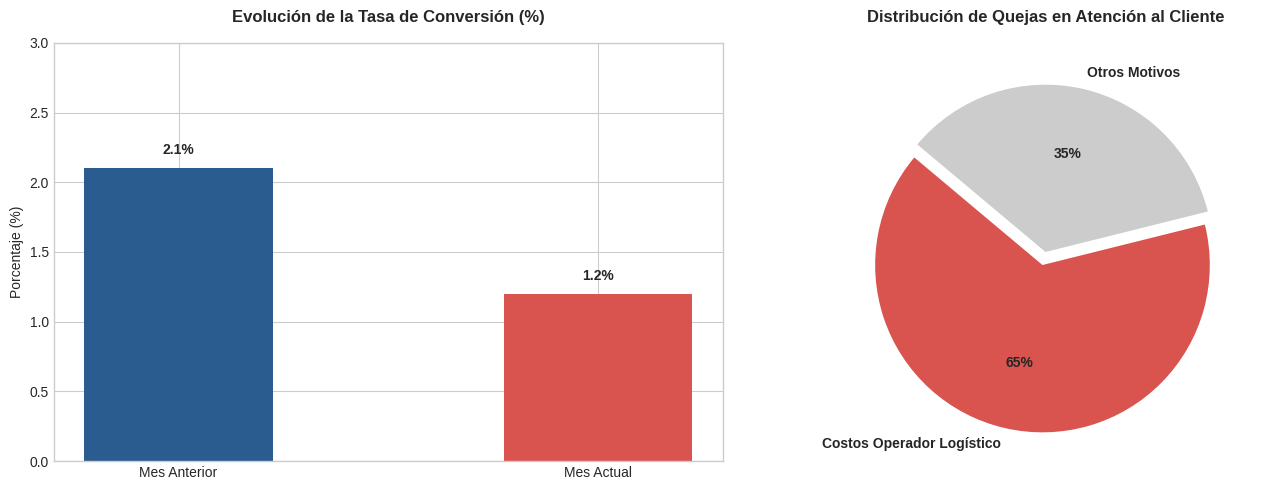

✓ Panel gráfico generado y guardado localmente como 'metricas_ejecutivas.png'.


In [4]:
# PASO 3: MÓDULO DE VISUALIZACIÓN CUANTITATIVA (MATPLOTLIB)

import matplotlib.pyplot as plt

# Configuración de estilo visual para informe ejecutivo
plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------------------------
# Gráfico 1: Caída de la Tasa de Conversión
# ------------------------------------------------------------------------------
periodos = ["Mes Anterior", "Mes Actual"]
conversion = [2.1, 1.2]  # Métricas en porcentaje
colores_barras = ["#2b5c8f", "#d9534f"]  # Azul corporativo vs Rojo alerta

bars = axes[0].bar(periodos, conversion, color=colores_barras, width=0.45)
axes[0].set_title(
    "Evolución de la Tasa de Conversión (%)",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
axes[0].set_ylabel("Porcentaje (%)", fontsize=10)
axes[0].set_ylim(0, 3)

for bar in bars:
    yval = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.08,
        f"{yval}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# ------------------------------------------------------------------------------
# Gráfico 2: Origen de las Quejas en Atención al Cliente
# ------------------------------------------------------------------------------
categorias_quejas = ["Costos Operador Logístico", "Otros Motivos"]
porcentajes_quejas = [65, 35]
colores_pie = ["#d9534f", "#cccccc"]

axes[1].pie(
    porcentajes_quejas,
    labels=categorias_quejas,
    autopct="%1.0f%%",
    startangle=140,
    colors=colores_pie,
    explode=(0.08, 0),
    textprops={"fontweight": "bold"},
)
axes[1].set_title(
    "Distribución de Quejas en Atención al Cliente",
    fontsize=12,
    fontweight="bold",
    pad=15,
)

plt.tight_layout()
plt.savefig("metricas_ejecutivas.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Panel gráfico generado y guardado localmente como 'metricas_ejecutivas.png'.")

In [ ]:
# ==============================================================================
# PASO 4: INTEGRACIÓN DE PORTADA CONCEPTUAL Y CONCLUSIONES
# ==============================================================================
from IPython.display import Image, Markdown, display

# 1. Intentar cargar la imagen de portada
nombre_imagen = "portada_datastory.png"

try:
    display(Image(filename=nombre_imagen, width=600))
    print("✓ Portada visualizada correctamente.")
except Exception:
    print(
        f"⚠ No se encontró '{nombre_imagen}' en Colab. Si querés verla, subí el archivo al panel izquierdo."
    )

# 2. Conclusiones finales (usando cadenas estándar para evitar errores de sintaxis)
linea1 = "### Conclusiones del Informe Ejecutivo (POC)\n"
linea2 = (
    "- **Diagnóstico:** El problema no es la pauta publicitaria (+20% tráfico),"
    " sino la fricción en el checkout por los costos del nuevo operador"
    " logístico (+40% abandono).\n"
)
linea3 = (
    "- **Módulo Técnico:** Quedó validada la integración entre la API de Groq"
    " para la narrativa y Matplotlib para la visualización cuantitativa."
)

texto_conclusiones = linea1 + linea2 + linea3
display(Markdown(texto_conclusiones))

⚠ No se encontró 'portada_datastory.png' en Colab. Si querés verla, subí el archivo al panel izquierdo.


### Conclusiones del Informe Ejecutivo (POC)
- **Diagnóstico:** El problema no es la pauta publicitaria (+20% tráfico), sino la fricción en el checkout por los costos del nuevo operador logístico (+40% abandono).
- **Módulo Técnico:** Quedó validada la integración entre la API de Groq para la narrativa y Matplotlib para la visualización cuantitativa.